# Generalization

We should consider that looking just at the training accuracy can lead a **false sense of security**. Imagine a scenario where you want to train a neural network to recognize shoes. It's like teaching somebody who had never seen a shoe before about what a shoe actually is so that in the future when they see an object, they can decide whether what they're seeing is a shoe or not. Now, we know there's a huge variety of shoes, and there's no hard and fast rule about what makes a shoe a "shoe". 

<img src="./images/017.png" width="500">

Typically, the steps that you'd follow are to get as many examples of shoes as possible, train a neural network using those examples, and then profit. Earlier, we trained neural networks to recognize handwriting images and Zalando goods and they needed 60,000 examples. That will be a lot of shoes if you were going to try to train it with shoes instead. But you'd still have to gather as many shoes as possible and train by looking at them:

<img src="./images/018.png" width="700">

You might end up with a model of increasing accuracy number as you train. By the time it finishes training, it has a very high accuracy, maybe even 100%. Now that might mean you think you've written an amazing AI that can recognize shoes, and it's time to profit. But then you show it a shoe like this, and it fails:

<img src="./images/019.png" width="300">

You thought you were 100% accurate in recognizing shoes. But the reality is that you are 100% accurate at **recognizing the types of shoe that you trained the neural network on** and that 100% figure led you to a false sense of security. Your perfect neural network architecture may not be so perfect after all. There's a number of ways to help prevent this.

We used all of our data to train our neural networks, and why not? The more we train, the better, right? In principle this sounds fine, but we've no way of testing it against previously **unseen data** because we used all of our data to train it. So what if we hold back some of the data? Don't train with all of the data. Save some for **testing** that the neural network is training well after it is trained. The split ratio is commonly represented as a percentage between 0 and 1. A ratio of train: 80% and test: 20% will be represented as 0.80 for training and 0.20 for testing. We can also divide the test set and definte also some **validation data** that can be used to validate the model during the training process. The information from the validation process assists us in changing parameters, classifiers of the model to get better results. So basically, validation data helps us to optimize the model. 

<img src="./images/020.png" width="400">

We can update our training in order to use only the training set to train the network and then test is on the test set:

In [4]:
import tensorflow as tf
tf.get_logger().setLevel('ERROR')
fashion = tf.keras.datasets.fashion_mnist

(training_images, training_labels), (test_images, test_labels) = fashion.load_data()
training_images = training_images / 255.0
test_images = test_images / 255.0

In [5]:
model = tf.keras.models.Sequential([
  tf.keras.layers.Flatten(),
  tf.keras.layers.Dense(20, activation=tf.nn.relu),
  tf.keras.layers.Dense(10, activation=tf.nn.softmax)
])

In [6]:
model.compile(optimizer='adam', 
              loss='sparse_categorical_crossentropy', 
              metrics=['accuracy'])

In [7]:
result = model.fit(training_images, training_labels, epochs=20, verbose=0)
model.evaluate(training_images, training_labels)

1875/1875 [==============================] - 2s 767us/step - loss: 0.2693 - accuracy: 0.9024


[0.26927706599235535, 0.9024166464805603]

Then we make the validation of the model on the test set:

In [8]:
model.evaluate(test_images, test_labels)

313/313 [==============================] - 0s 771us/step - loss: 0.3781 - accuracy: 0.8695


[0.37805554270744324, 0.8694999814033508]

The accuracy is slightly lower than the one provided during training. This is because the model hasn't previously seen the test data and may not **fully generalize** for all data. We can also split the training set in order to get a validation set to be used during training to evaluate the generalization performance during training. We put 5000 into validation set and keep remaining 55.000 for training:

In [9]:
(training_images, validation_images) = training_images[5000:], training_images[:5000] 
(training_labels, validation_labels) = training_labels[5000:], training_labels[:5000]

In [10]:
model = tf.keras.models.Sequential([
  tf.keras.layers.Flatten(),
  tf.keras.layers.Dense(20, activation=tf.nn.relu),
  tf.keras.layers.Dense(10, activation=tf.nn.softmax)
])

In [11]:
model.compile(optimizer='adam', 
              loss='sparse_categorical_crossentropy', 
              metrics=['accuracy'])

In [12]:
result = model.fit(training_images, training_labels, 
          validation_data=(validation_images, validation_labels),
          epochs=20, verbose=0)

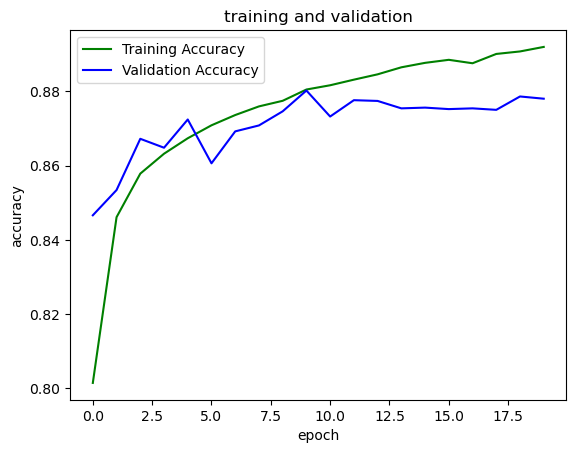

In [13]:
import matplotlib.pyplot as plt

plt.plot(result.history['accuracy'], 'g', label='Training Accuracy')
plt.plot(result.history['val_accuracy'], 'b', label='Validation Accuracy')
plt.title('training and validation')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend()
plt.show()

Our goal is to strive to get the two accuracy (training and validation) as close to each other as possible: this is a sign that our neural network is **good at generalizing and not over specializing** to the training data. Finally you perform model.evaluate() on the testing set after training is complete to see the results. Your confidence and your network's ability to classify data should be based on this value and not the training one.

In [14]:
model.evaluate(test_images, test_labels)

313/313 [==============================] - 0s 743us/step - loss: 0.3941 - accuracy: 0.8628


[0.39413580298423767, 0.8628000020980835]

Let's take a look at more realistic content: larger color images where the subject isn't necessarily centered. With MNIST or Fashion-MNIST, it is very simple to get the dataset: we simply load it from Tensorflow and it gave us a set of training images and labels and the same for test images and labels. But it's not always that simple. A useful dataset for learning is the [**Horses or Humans dataset**](https://www.kaggle.com/datasets/sanikamal/horses-or-humans-dataset): it has over 1,000 images that are 300 by 300 in full color of horses and humans in various poses, unlike MNIST and Fashion-MNIST, they're not centered in the frame and sometimes they're not the only content:

<img src="./images/033.png" width="450">

A methodology in TensorFlow to handle datasets is to create folders containing the images and provide the labels using the parent folder name: 

<img src="./images/034.png" width="600">

Then you can use the **Image Data Generator** to turn folders into a trainable pipeline. First of all we have to download the dataset locally:

In [ ]:
!wget --no-check-certificate --no-verbose https://www.dropbox.com/s/aj2a4bp5pgmh6ph/horse-or-human.zip

Then we extract files from the zip archive:

In [ ]:
import zipfile

local_zip = './horse-or-human.zip'
zip_ref = zipfile.ZipFile(local_zip, 'r')
zip_ref.extractall('.')
zip_ref.close()

In [ ]:
import os

train_horse_dir = os.path.join('./horse-or-human/training/horses')
train_human_dir = os.path.join('./horse-or-human/training/humans')
validation_horse_dir = os.path.join('./horse-or-human/validation/horses')
validation_human_dir = os.path.join('./horse-or-human/validation/humans')

train_horse_names = os.listdir('./horse-or-human/training/horses')
train_human_names = os.listdir('./horse-or-human/training/humans')
validation_horse_hames = os.listdir('./horse-or-human/validation/horses')
validation_human_names = os.listdir('./horse-or-human/validation/humans')

We can create the operation that we want to do using the ImageDataGenerator class, in this case we just normalize pixel values:

In [ ]:
import tensorflow as tf
tf.get_logger().setLevel('ERROR')
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(rescale=1./255)
validation_datagen = ImageDataGenerator(rescale=1./255)

Then we can flow images on the generator specifiyng the path of the folder containing the  images. We can also specify the target size of the image (so if they are of different sizes, the generator will resize them to this), the batch size (how many images it has to elaborate at a time) and finally the class mode: binary (when there are two classes) or categorical (when there are more than two classes).

In [ ]:
train_generator = train_datagen.flow_from_directory('./horse-or-human/training',  
                                                    target_size=(100, 100),  
                                                    batch_size=128,
                                                    class_mode='binary')

validation_generator = validation_datagen.flow_from_directory('./horse-or-human/validation',
                                                              target_size=(100, 100),
                                                              class_mode='binary')

Now we can design our model architecture. We have large images containing complex features, so we try with four layers of convolutions each with an associated pooling. And then finally we have our output layer. We have two classes, which would normally have two output neurons. But one other option they can do is to use a single neuron and set the activation function to sigmoid. This will pull the output value towards 0 for one class and towards 1 for the other:

In [ ]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(100, 100, 3)),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Conv2D(256, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

In [ ]:
print(model.summary())

As always, we compile our model specifying a loss function and an optimizer. In this case, we can try a different optimizer, RMSprop (Root Mean Square Propagation): it's always good to experiment with different ones.

In [ ]:
from tensorflow.keras.optimizers import RMSprop

model.compile(loss='binary_crossentropy',
              optimizer=RMSprop(learning_rate = 0.0001),
              metrics=['acc'])

Now when we do our model.fit() informing the function to use the generators for the training and validation data:

In [ ]:
results = model.fit(train_generator,
                    steps_per_epoch = 8,  
                    epochs = 50,
                    verbose = 0,
                    validation_data = validation_generator)

In [ ]:
print('Training Accuracy: ', results.history['acc'][49])
print('Validation Accuracy: ', results.history['val_acc'][49])

The horses or humans data set is quite small, so when we are training on it, we might get lulled into **a false sense of security** that our network is more accurate than it is at seeing and recognizing images. Imagine if the only shoes you had ever seen in your life were hiking boots. Now, even though hiking boots come in lots of different shapes, and sizes, and colors, and models, by looking at many of them, you'll soon think that all shoes were hiking boots. And then, you could get very good at identifying them. And as you're using the features that make up a hiking boot to determine that it's a shoe, things
like the size or the location within the image wouldn't faze you. You'd have no trouble with an image like this:

<img src="./images/035.png" width="300">

But then you see a shoe like this:

<img src="./images/036.png" width="200">

And you don't recognize it as a shoe. Even though it really is one, you've overfed yourself into thinking that all shoes look like hiking boots. Let's take a look at actually running a prediction using the model. This code runs several random images of human and horses taken from Internet through the model, giving an indication of whether the object is a horse or a human. Was the model correct?

In [ ]:
import numpy as np
from tensorflow.keras import utils
import matplotlib.pyplot as plt

def make_predictions(images):
    rows = 3
    columns = 4
    index = 1
    fig = plt.figure(figsize=(20, 10))
    for image in images:
        x = utils.img_to_array(image)
        x = x / 255.0
        x = np.expand_dims(x, axis=0)
        image_tensor = np.vstack([x])
        prediction = model.predict(image_tensor)
        decision = ''
        if prediction > 0.7:
            decision += 'It is a human ' + str(prediction)
        elif prediction < 0.3: 
            decision += 'It is a horse ' + str(prediction)
        else :
            decision += 'mmm...I''m not sure ' + str(prediction)
        
        fig.add_subplot(rows, columns, index)
        plt.imshow(image)
        plt.text(5, 105, decision)
        plt.axis('off')
        index += 1

In [ ]:
import glob
test_files = glob.glob('./horse-or-human/test/*.png')
images = []

for file in test_files:
    images.append(utils.load_img(file, target_size=(100, 100)))

In [ ]:
make_predictions(images)

While results might seem really good on training, the validation (and test) results may actually go down, due to something called **overfitting**: the network learns data from the training set really well, but it is too specialised to only that data, and as a result is less effective at seeing other data. For example, if all your life you only saw red shoes, then when you see a red shoe you would be very good at identifying it, but blue suade shoes might confuse you.

Let's consider how convolutional neural networks work in order to design improvements: they spot features in an image, like the ears of a cat, but if you only train on cat images that are upright, then the computer might only recognize ears that are oriented in that way as "ears". So it may not recognize an image of a cat just becouse ears are oriented differently:

<img src="./images/037.png" width="450">

But what if we rotate the image a little before training? Now, we'll have a labeled image of a cat with ears rotated. We can exploit the trasnformation provided by the image data generator. It can be done with the "rotation_range" parameter that rotate every image up the range degrees left or right, as it's read from the file system. By tweaking this parameter,  can impact how much the image is rotated.

<img src="./images/038.png" width="200">

Similarly, what if all of our images have the subject in the center of the image? It might not recognize some picture where the subject is shifted from the center. So shifting images around within the frames when training can help us to prevent overfitting here too. This is achieved using the "width_shift_range" and the 2height_shift_range" parameters.

<img src="./images/039.png" width="350">

Another augmentation that can be done is skewing, this can be useful in a scenario like the one in the picture, where the image on the left is clearly a human, but the training data has nothing like it. It has images with similar pose. So, if we skew the left image, we now have pixels that look like the left one. This type of sharing is achieved using the "shear range" parameter.

<img src="./images/040.png" width="600">

One more scenario: the woman on the left is obviously human, but her legs are not visible in the image. If the training dataset has only full body poses of human, the model might fail, because of the missing legs. But if we zoom in the image, it looks a lot like the one on the left. The "zoom_range" parameter achieves this.

<img src="./images/041.png" width="600">

Another really obvious one is flipping images. If our training set only has humans with their right hand raised, it might not be able to categorize pictures where the human has her left hand raised. We could overfit for right hand raisers mistakenly. But if we flip the image in our training data, we now have a left hand raiser too. This can be done with the "horizontal_flip" parameter.

<img src="./images/042.png" width="600">

There is many more parameters to explore.

One last thing to consider as the fill mode,  this is useful when the augmentation removes pixels. Usually we can use "nearest", which picks neighbor pixels and fills the gaps using them.

Augmentation can help with overfitting, but use it in moderation: too much can really slow down the training.

In [ ]:
train_datagen = ImageDataGenerator(rescale=1./255,
                                   rotation_range=20,
                                   width_shift_range=0.2,
                                   height_shift_range=0.2,
                                   shear_range=0.2,
                                   zoom_range=0.2,
                                   horizontal_flip=True,
                                   fill_mode='nearest')

In [ ]:
train_generator = train_datagen.flow_from_directory('./horse-or-human/training/',  
                                                    target_size=(100, 100),  
                                                    batch_size=128,
                                                    class_mode='binary')

In [ ]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(100, 100, 3)),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Conv2D(256, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

In [ ]:
model.compile(loss='binary_crossentropy',
              optimizer=RMSprop(learning_rate = 0.0001),
              metrics=['acc'])

In [ ]:
results = model.fit(train_generator, 
                    steps_per_epoch=8,
                    epochs=50,
                    verbose=0,
                    validation_data=validation_generator)

In [ ]:
print('Training Accuracy: ', results.history['acc'][49])
print('Validation Accuracy: ', results.history['val_acc'][49])

Try running the model again on the Internet images. Can we confuse it this time? Or did the extra data augmentation help the model generalize? What do you think it was about our confusing examples that are no longer confusing (or what is still confusing)?

In [ ]:
make_predictions(images)

In addition to the database augmentation, a technique to help overcome overfitting is use of the **dropout regularization**. When a neural network is being trained, each individual neuron will have an effect on neurons in subsequent layers. Over time, particularly in larger networks, some neurons can become overspecialized potentially causing the network as a whole to become overspecialized and leading to overfitting. Additionally, neighboring neurons can end up with similar weights and biases, and if not monitored this can lead the overall model to become overspecialized to the features activated by those neurons. While training, if you remove a random number of neurons and connections, and ignore them, their contribution to the neurons in the next layer are temporarily blocked. This reduces the chances of the neurons becoming overspecialized. The network will still learn the same number of parameters, but it should be better at generalization—that is, it should be more resilient to different inputs.

<img src="./images/043.png" width="400">

To implement this idea, we can just add the "Dropout" Keras layer to the network, specifying the percentage of neurons (like 20%) we want to remove in the specified layer. For example that demonstrates this, we can consider the Fashion MNIST classifier you explored earlier: 

In [ ]:
fashion = tf.keras.datasets.fashion_mnist
(training_images, training_labels), (validation_images, validation_labels) = fashion.load_data()
training_images = training_images / 255.0
validation_images = validation_images / 255.0

In [ ]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Flatten(input_shape=(28,28)),
    tf.keras.layers.Dense(256, activation=tf.nn.relu),
    tf.keras.layers.Dense(128, activation=tf.nn.relu),
    tf.keras.layers.Dense(64, activation=tf.nn.relu),
    tf.keras.layers.Dense(10, activation=tf.nn.softmax)
])

Training this for 100 epochs gave around 98% accuracy on the training set, and about 88% on the validation set. This is a sign of potential overfitting.

In [ ]:
model.compile(optimizer='adam', 
              loss='sparse_categorical_crossentropy', 
              metrics=['accuracy'])

In [ ]:
results = model.fit(training_images, training_labels,
                   validation_data=(validation_images, validation_labels),
                   epochs=100, verbose=0)

In [ ]:
print('Training Accuracy: ', results.history['accuracy'][99])
print('Validation Accuracy: ', results.history['val_accuracy'][99])

In [ ]:
plt.plot(results.history['accuracy'], 'g', label='Training Accuracy')
plt.plot(results.history['val_accuracy'], 'b', label='Validation Accuracy')
plt.title('training and validation')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend()
plt.show()

Introducing dropouts after each dense layer looks like this:

In [ ]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Flatten(input_shape=(28,28)),
    tf.keras.layers.Dense(256, activation=tf.nn.relu),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(128, activation=tf.nn.relu),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(64, activation=tf.nn.relu),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(10, activation=tf.nn.softmax)
])

In [ ]:
model.compile(optimizer='adam', 
              loss='sparse_categorical_crossentropy', 
              metrics=['accuracy'])

In [ ]:
results = model.fit(training_images, training_labels,
                   validation_data=(validation_images, validation_labels),
                   epochs=100, verbose=0)

In [ ]:
print('Training Accuracy: ', results.history['accuracy'][99])
print('Validation Accuracy: ', results.history['val_accuracy'][99])

In [ ]:
plt.plot(results.history['accuracy'], 'g', label='Training Accuracy')
plt.plot(results.history['val_accuracy'], 'b', label='Validation Accuracy')
plt.title('training and validation')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend()
plt.show()

The accuracy on the training set dropped to about 04%. The accuracy on the validation set stayed about the same, at 89%. These values are much closer to each other. The introduction of dropouts demonstrated that overfitting was occurring, but also that adding them can help remove it by ensuring that the network isn’t overspecializing to the training data.

An handy tool to flow data into network for training is [**TensorFlow Datasets (TDFS)**](https://www.tensorflow.org/datasets). It exposes datasets in a way that’s easy to consume, where all the preprocessing steps of acquiring the data and getting it into TensorFlow APIs is seamless. We already seen athis idea with how Keras handled Fashion MNIST:

In [ ]:
data = tf.keras.datasets.fashion_mnist

(training_images, training_labels), (test_images, test_labels) = data.load_data()

TFDS builds on this idea, but it expands the number of datasets available and the diversity of dataset types. The [list of available datasets](https://www.tensorflow.org/datasets/catalog/robomimic_mg) is growing all the time including pictures, text, audio, video and more.

We can use it to get access to a dataset using its name:

In [ ]:
import tensorflow as tf
import tensorflow_datasets as tfds

mnist_data = tfds.load("fashion_mnist")

for item in mnist_data:
    print(item)

Two important concepts of TFDS are the **Splits** (that gives flexiblility of splitting up data into training, testing and validation sets) and **Mapping** (to do things like augmentation):

In [ ]:
def augment_images(image, label):
    image = tf.cast(image, tf.float32)
    image = (image/255)
    image = tf.image.random_flip_left_right(image)
    return image, label

data = tfds.load('horses_or_humans', split='train', as_supervised=True)

train = data.map(augment_images)